# **Импорты**

In [ ]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam, Adadelta, SGD

# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Связь с google-диском
from google.colab import files

# Предварительная обработка данных
from sklearn import preprocessing

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from keras.datasets import fashion_mnist

# Отрисовывать изображения в ноутбуке, а не в консоль или файл
%matplotlib inline

# **Загрузка данных**

In [12]:
# Загрузка датасета
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Вывод размерностей выборок

print('Размер x_train:',x_train.shape)
print('Размер y_train:',y_train.shape)
print('Размер x_test:',x_test.shape)
print('Размер y_test:',y_test.shape)

Размер x_train: (60000, 28, 28)
Размер y_train: (60000,)
Размер x_test: (10000, 28, 28)
Размер y_test: (10000,)


# **Первичная обработка изображений**

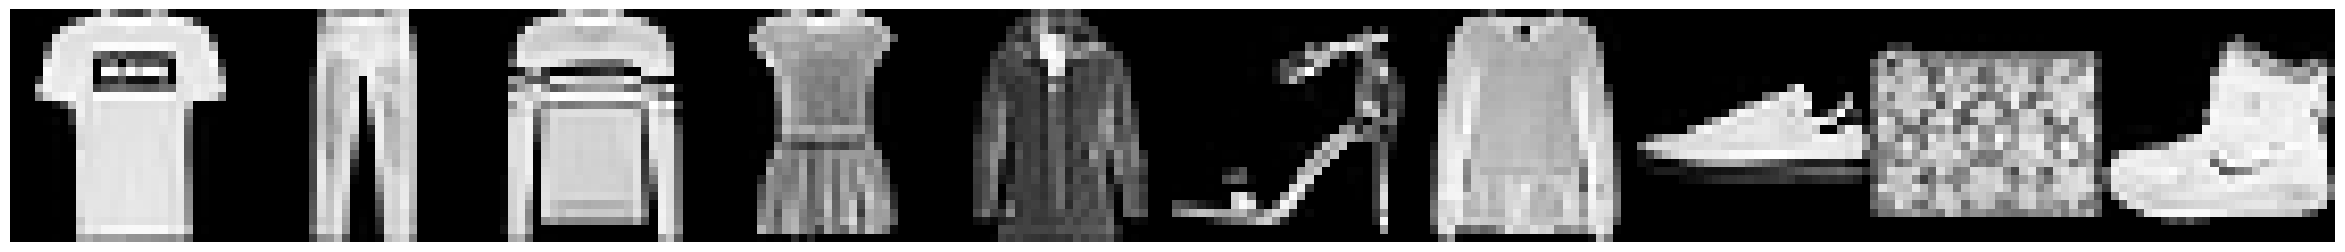

In [13]:
# Выбор 1 изображения каждого класса
imgs = np.array([x_train[y_train==i][0] for i in range(10)])

# Соединение изображения в одну линию
imgs = np.concatenate(imgs, axis=1)

# Создание поля для изображения
plt.figure(figsize=(30, 6))

# Отрисовка итогового изображения
plt.imshow(imgs, cmap='Greys_r')

# Без сетки
plt.grid(False)

# Без осей
plt.axis('off')

# Вывод результата
plt.show()

# **Подготовка данных**

In [14]:
# Нормализация данных (приведение к диапазону [0,1])
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Преобразование 2D-изображений (28x28) в 1D-вектора (784)
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

# Преобразование меток в one-hot encoding
y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)

# Разделение обучающей выборки (60000) на обучение (50000) и проверку (10000)
# Используем stratify для сохранения распределения классов
x_train_part, x_val, y_train_part, y_val = train_test_split(
    x_train_flat, y_train_cat, train_size=50000, random_state=42, stratify=y_train_cat
)

print('Размер обучающей выборки:', x_train_part.shape[0])
print('Размер проверочной выборки:', x_val.shape[0])
print('Размер тестовой выборки:', x_test_flat.shape[0])

Размер обучающей выборки: 50000
Размер проверочной выборки: 10000
Размер тестовой выборки: 10000


# **Вспомогательная функция для обучения модели**

In [15]:
def train_model(model, name, epochs=20, batch_size=128):
    """
    Обучает модель и возвращает историю, точность на проверке и точность на тесте.
    """
    print(f'\nОбучение модели: {name}')
    history = model.fit(
        x_train_part, y_train_part,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0  # 0 - тихо, 1 - подробно
    )
    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)
    print(f'Точность на проверке: {val_acc:.4f}, на тесте: {test_acc:.4f}')
    return history, val_acc, test_acc

# **Создание 9 моделей**

In [16]:
# Модель 1: один скрытый слой (128)
model1 = Sequential([
    Dense(128, input_shape=(784,), activation='relu'),
    Dense(10, activation='softmax')
])
model1.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 2: два скрытых слоя (256, 128)
model2 = Sequential([
    Dense(256, input_shape=(784,), activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model2.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 3: три скрытых слоя (512, 256, 128)
model3 = Sequential([
    Dense(512, input_shape=(784,), activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model3.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 4: с Dropout (0.5)
model4 = Sequential([
    Dense(256, input_shape=(784,), activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model4.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 5: с BatchNormalization
model5 = Sequential([
    Dense(256, input_shape=(784,)),
    BatchNormalization(),
    Activation('relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model5.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 6: с функцией активации tanh
model6 = Sequential([
    Dense(256, input_shape=(784,), activation='tanh'),
    Dense(128, activation='tanh'),
    Dense(10, activation='softmax')
])
model6.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 7: маленькая сеть (64, 32)
model7 = Sequential([
    Dense(64, input_shape=(784,), activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
model7.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 8: большая сеть (1024, 512)
model8 = Sequential([
    Dense(1024, input_shape=(784,), activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])
model8.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Модель 9: комбинированная (Dropout + BatchNorm + SGD)
model9 = Sequential([
    Dense(512, input_shape=(784,), activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model9.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Списки для удобства
models = [model1, model2, model3, model4, model5, model6, model7, model8, model9]
names = [
    '1_layer_128',
    '2_layers_256_128',
    '3_layers_512_256_128',
    'dropout_0.5',
    'batchnorm',
    'tanh',
    'small_64_32',
    'large_1024_512',
    'combined_SGD'
]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Обучение всех моделей**

In [17]:
results = []
histories = []

for model, name in zip(models, names):
    history, val_acc, test_acc = train_model(model, name, epochs=20)
    results.append({
        'Модель': name,
        'Точность на проверке': val_acc,
        'Точность на тесте': test_acc
    })
    histories.append(history)


Обучение модели: 1_layer_128
Точность на проверке: 0.8890, на тесте: 0.8837

Обучение модели: 2_layers_256_128
Точность на проверке: 0.8921, на тесте: 0.8847

Обучение модели: 3_layers_512_256_128
Точность на проверке: 0.8937, на тесте: 0.8901

Обучение модели: dropout_0.5
Точность на проверке: 0.8940, на тесте: 0.8868

Обучение модели: batchnorm
Точность на проверке: 0.8854, на тесте: 0.8818

Обучение модели: tanh
Точность на проверке: 0.8931, на тесте: 0.8828

Обучение модели: small_64_32
Точность на проверке: 0.8861, на тесте: 0.8810

Обучение модели: large_1024_512
Точность на проверке: 0.8979, на тесте: 0.8892

Обучение модели: combined_SGD
Точность на проверке: 0.8930, на тесте: 0.8930


# Сравнительная таблица

In [19]:
df_results = pd.DataFrame(results)
print('Сравнительная таблица результатов:')
print(df_results.to_string(index=False))

Сравнительная таблица результатов:
              Модель  Точность на проверке  Точность на тесте
         1_layer_128                0.8890             0.8837
    2_layers_256_128                0.8921             0.8847
3_layers_512_256_128                0.8937             0.8901
         dropout_0.5                0.8940             0.8868
           batchnorm                0.8854             0.8818
                tanh                0.8931             0.8828
         small_64_32                0.8861             0.8810
      large_1024_512                0.8979             0.8892
        combined_SGD                0.8930             0.8930
